In [1]:
from config_loader import load_raw
import prepare_inputs as prep
import numpy as np

raw = load_raw("paths.nml", "run.nml")

root_frac_by_lu, root_params_by_lu = prep.build_root_frac_by_lu(
    landcover_df=raw.landcover,
    root_params_df=raw.root_params,
    layer_edges_m=raw.layer_edges_m,
    wetland_proxy_type=raw.wetland_proxy_type,
    strict=True,
)

lai_daily_by_lu = prep.build_lai_daily_by_lu(
    landcover_df=raw.landcover,
    lai_cycles_doy=raw.lai_cycles_doy,
    start_date=raw.start_dt,
    end_date=raw.end_dt,
    strict=False,   # warn + LAI=0 if missing
)


2026-02-16 12:09:30,913 | INFO | Exported derived soil hydraulic properties to W:\VUB\_main_research\scripts\wetland_model\conceptual_model\model_setup_v2_2025\inputs\soil\soil_hydraulic_properties.csv


In [3]:
root_frac_by_lu

{'Bare': array([0., 0., 0., 0.]),
 'Deciduous broadleaf forest': array([0.18079405, 0.62764319, 0.14497968, 0.04658309]),
 'Grassland': array([0.27159433, 0.59906351, 0.1022195 , 0.02712266])}

In [7]:
from config_loader import load_raw
from forcings import build_forcing

raw = load_raw("paths.nml", "run.nml")

forcing = build_forcing(
    meteo_daily=raw.meteo,
    dn_ratios_df=raw.dn_ratios,
    latitude=raw.latitude,
    sim_freq=raw.sim_freq,
    precip_method=raw.precip_method,
    pet_method=raw.pet_method,
    fnight_pet=raw.fnight_pet,
)

In [8]:
from model_processes import run_canopy_wb, initialize_model_fluxes

raw = load_raw("paths.nml", "run.nml")

flux_arrays, TF_by_lu, Ec_by_lu, I_by_lu = run_canopy_wb(
    forcing=forcing,
    flux_arrays=initialize_model_fluxes(forcing.index, raw.sim_freq, n_layers=raw.layer_edges_m.size - 1),
    sim_freq=raw.sim_freq,
    lu_types=raw.landcover["lu_type"],
    lu_fracs=raw.landcover["lu_frac"],
    lai_daily_by_lu=lai_daily_by_lu,
    I0=0.0
)

Running Canopy WB (multi-LU):   0%|          | 0/149040 [00:00<?, ?it/s]

In [ ]:
from model_processes import soil_water_balance_nlayers_multi_lu

sp = raw.soil_params_layer
z_layers = np.diff(np.asarray(raw.layer_edges_m, dtype=float)) * 1000.0  # thicknesses in mm

# soil
model_fluxes = soil_water_balance_nlayers_multi_lu(
    model_fluxes=flux_arrays,
    forcing=forcing,
    z_layers=z_layers,
    theta_sat=sp["theta_sat"],
    theta_fc=sp["theta_fc"],
    theta_wp=sp["theta_wp"],
    Ks_mm_h=sp["Ks_mm_h"],
    theta_r=sp["theta_r"],
    b_param=sp["b"],
    lu_types=raw.landcover["lu_type"],
    lu_fracs=raw.landcover["lu_frac"],
    root_frac_by_lu=root_frac_by_lu,
    TF_by_lu=TF_by_lu,
    Ec_by_lu=Ec_by_lu,
    sim_freq=raw.sim_freq,
)

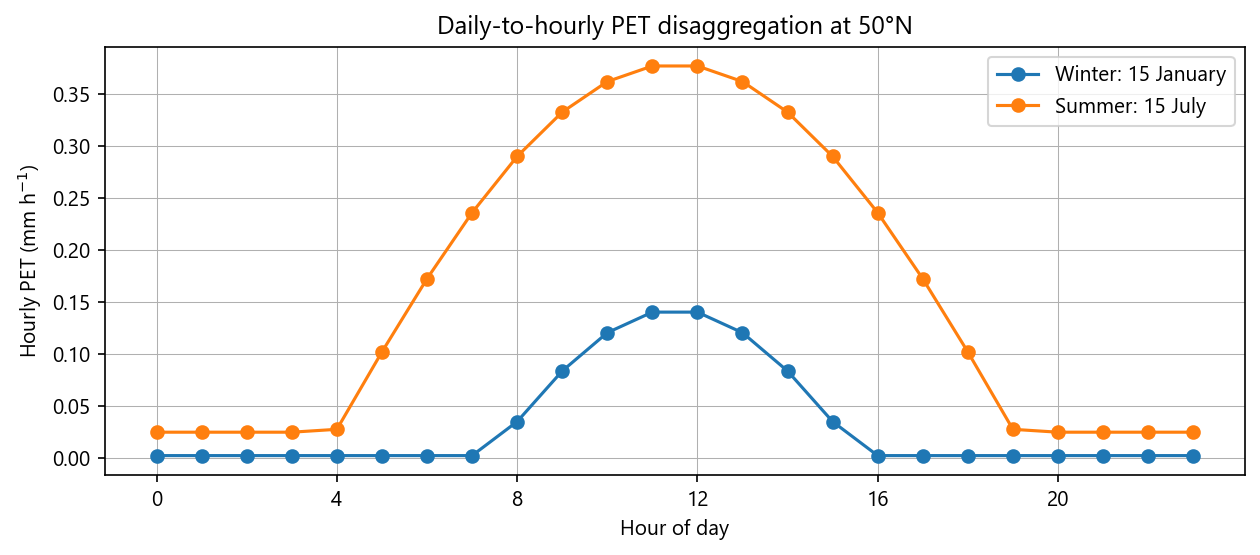

Summary:
              case  day_of_year  daily_PET_mm  declination_deg  daylength_h  sunrise_h  sunset_h  daylight_steps  night_steps  sum_hourly_PET_mm  max_hourly_PET_mm_h
Winter: 15 January           15           0.8         -21.2604       8.3165     7.8417   16.1583               8           16                0.8               0.1404
   Summer: 15 July          196           4.0          21.5082      15.7348     4.1326   19.8674              16            8                4.0               0.3770

Hourly values:
 hour  winter_Jan15_PET_h_mm  summer_Jul15_PET_h_mm
    0                 0.0025                 0.0250
    1                 0.0025                 0.0250
    2                 0.0025                 0.0250
    3                 0.0025                 0.0250
    4                 0.0025                 0.0278
    5                 0.0025                 0.1022
    6                 0.0025                 0.1725
    7                 0.0025                 0.2360
    8    

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#segoeu ui font
plt.rcParams["font.family"] = "Segoe UI"

def pet_disaggregation_example(latitude, PET_d, fnight_pet, J, label):
    hours = np.arange(24)
    hour_centres = hours + 0.5

    phi = np.deg2rad(latitude)
    delta = np.deg2rad(23.44) * np.sin(2 * np.pi * (284 + J) / 365.0)

    x = -np.tan(phi) * np.tan(delta)
    x = np.clip(x, -1.0, 1.0)
    omega = np.arccos(x)
    N_day = 24.0 / np.pi * omega

    sunrise = 12.0 - N_day / 2.0
    sunset = 12.0 + N_day / 2.0

    day_mask = (hour_centres >= sunrise) & (hour_centres < sunset)

    PET_night = PET_d * fnight_pet
    PET_day = PET_d - PET_night
    N_night = np.sum(~day_mask)

    PET_h = np.zeros(24)

    if N_night > 0:
        PET_h[~day_mask] = PET_night / N_night

    if PET_day > 0 and day_mask.any():
        t = (hour_centres[day_mask] - sunrise) / N_day
        w_tilde = np.sin(np.pi * t)
        PET_h[day_mask] = PET_day * w_tilde / w_tilde.sum()

    return {
        "label": label,
        "J": J,
        "latitude": latitude,
        "PET_d": PET_d,
        "fnight_pet": fnight_pet,
        "delta_deg": np.rad2deg(delta),
        "N_day": N_day,
        "sunrise": sunrise,
        "sunset": sunset,
        "N_daylight_steps": int(day_mask.sum()),
        "N_night_steps": int(N_night),
        "PET_h": PET_h,
        "day_mask": day_mask,
    }

latitude = 50.0
fnight_pet = 0.05

# Example daily PET totals are illustrative: lower in winter, higher in summer
winter = pet_disaggregation_example(latitude, PET_d=0.8, fnight_pet=fnight_pet, J=15, label="Winter: 15 January")
summer = pet_disaggregation_example(latitude, PET_d=4.0, fnight_pet=fnight_pet, J=196, label="Summer: 15 July")

hours = np.arange(24)

fig, ax = plt.subplots(figsize=(8.5, 3.8), dpi=150)
#at 4h intervls x-axis
ax.plot(hours, winter["PET_h"], marker="o", label=winter["label"])
ax.set_xticks(hours[::4])
ax.plot(hours, summer["PET_h"], marker="o", label=summer["label"])
ax.set_xlabel("Hour of day")
ax.set_ylabel("Hourly PET (mm h$^{-1}$)")
ax.set_title("Daily-to-hourly PET disaggregation at 50°N")
ax.grid(True, linewidth=0.5)
ax.legend()
plt.tight_layout()

plt.show()

rows = []
for result in [winter, summer]:
    rows.append({
        "case": result["label"],
        "day_of_year": result["J"],
        "daily_PET_mm": result["PET_d"],
        "declination_deg": result["delta_deg"],
        "daylength_h": result["N_day"],
        "sunrise_h": result["sunrise"],
        "sunset_h": result["sunset"],
        "daylight_steps": result["N_daylight_steps"],
        "night_steps": result["N_night_steps"],
        "sum_hourly_PET_mm": result["PET_h"].sum(),
        "max_hourly_PET_mm_h": result["PET_h"].max(),
    })

summary = pd.DataFrame(rows)

hourly = pd.DataFrame({
    "hour": hours,
    "winter_Jan15_PET_h_mm": winter["PET_h"],
    "summer_Jul15_PET_h_mm": summer["PET_h"],
})

print("Summary:")
print(summary.round(4).to_string(index=False))
print("\nHourly values:")
print(hourly.round(4).to_string(index=False))